In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import scipy 
import pandas as pd
import h5py
from pathlib import Path


print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Pandas:", pd.__version__)
print("h5py:", h5py.__version__)

NumPy: 2.4.6
SciPy: 1.17.1
Pandas: 3.0.3
h5py: 3.16.0


In [2]:
def get_thinfilm_file_path(parent_dir, Ca, Re, theta, f):
    parent_dir = Path(parent_dir)

    folder_name = (
        f"Ca_{Ca:07.4f}_"
        f"Re_{Re:07.3f}_"
        f"theta_{theta:06.3f}_"
        f"f_{f:05.2f}Hz"
    )

    file_path = parent_dir / folder_name / "thinfilm_training_data.h5"

    if not file_path.exists():
        raise FileNotFoundError(
            f"HDF5 file not found:\n{file_path}"
        )

    return file_path

In [3]:
#Parent directory for white noise data
# parent_dir = r"/blue/bala1s/krishnap.kalivel/TLFHydrodynamics/thinfilm-closure-ml/datasets/ROM_Ca_Re_sweep"

#Parent directory for constant frequency data
parent_dir = r"/blue/bala1s/krishnap.kalivel/TLFHydrodynamics/thinfilm-closure-ml/datasets/frequency_Ca_Re_theta_sweep"

In [4]:
Ca_values = [0.001, 0.01, 0.1]
Re_values = [5, 20, 40, 60, 80]
# theta = 6.4
# f = 3.0

theta = 45.0
f = 10.0

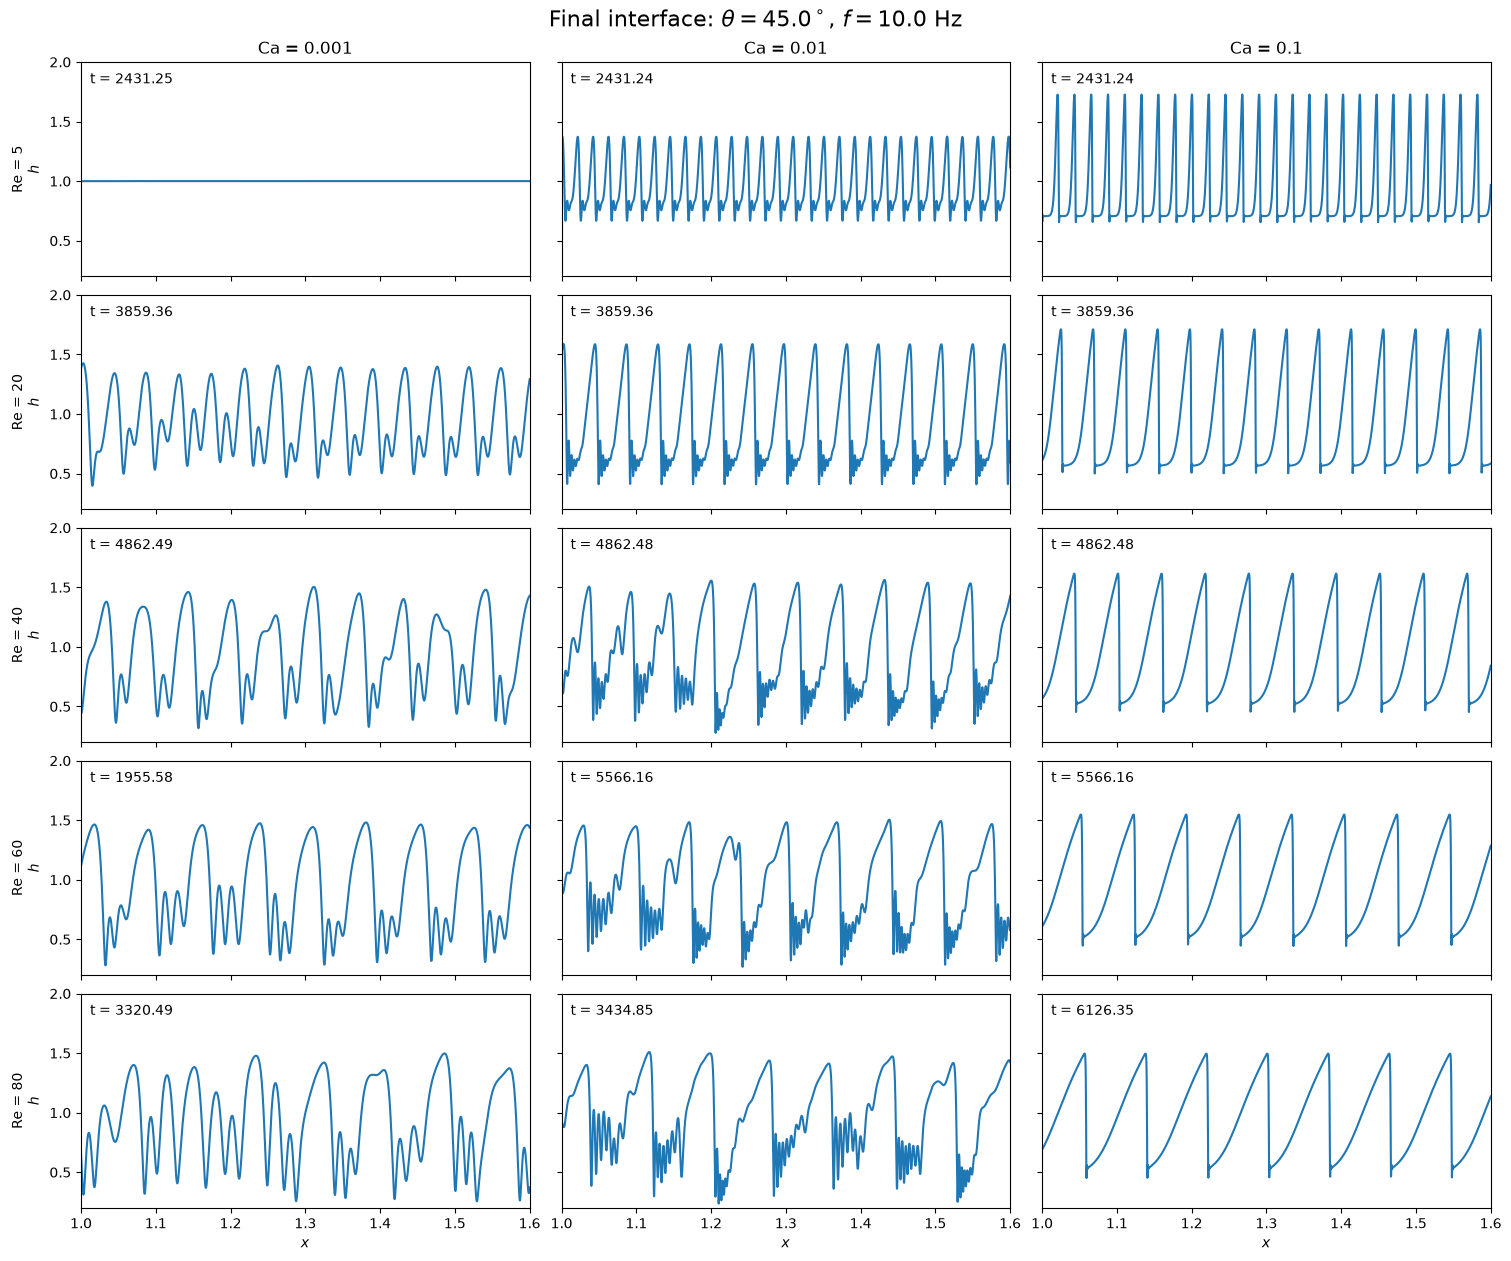

In [5]:
nrows = len(Re_values)
ncols = len(Ca_values)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 2.5 * nrows),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# Make axes always 2D
axes = np.atleast_2d(axes)

for i, Re in enumerate(Re_values):
    for j, Ca in enumerate(Ca_values):

        ax = axes[i, j]

        try:
            file_path = get_thinfilm_file_path(
                parent_dir,
                Ca=Ca,
                Re=Re,
                theta=theta,
                f=f
            )

            with h5py.File(file_path, "r") as file:
                x = file["x"][:].squeeze()
                time = file["time"][:].squeeze()
                h_final = file["h"][:, -1]
                hN = file.attrs["hN"][0]

            ax.plot(x*hN, h_final)

            # Show final time inside panel
            ax.text(
                0.02,
                0.95,
                f"t = {time[-1]:.2f}",
                transform=ax.transAxes,
                va="top"
            )

        except FileNotFoundError:
            ax.text(
                0.5,
                0.5,
                "File not found",
                transform=ax.transAxes,
                ha="center",
                va="center"
            )

        # Column titles = Ca
        if i == 0:
            ax.set_title(f"Ca = {Ca:g}")

        # Row labels = Re
        if j == 0:
            ax.set_ylabel(f"Re = {Re}\n$h$")

        # x labels only on bottom row
        if i == nrows - 1:
            ax.set_xlabel("$x$")
            
        ax.set_xlim(1.0, 1.6)
        ax.set_ylim(0.2, 2.0)


fig.suptitle(
    rf"Final interface: $\theta={theta}^\circ$, $f={f}$ Hz",
    fontsize=16
)

plt.show()

In [8]:
with h5py.File(file_path, "r") as f:

    print("Root attributes:")
    for key, value in f.attrs.items():
        print(f"  {key}: {value}")

    print("\nHDF5 contents:")

    def show_item(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"Dataset: {name}")
            print(f"  shape = {obj.shape}")
            print(f"  dtype = {obj.dtype}")
        elif isinstance(obj, h5py.Group):
            print(f"Group: {name}")

    f.visititems(show_item)


Root attributes:
  Ca: [0.1]
  F0: [0.05]
  F2: [18.85618083]
  Re: [80.]
  TN: [0.00244843]
  We: [8.]
  f_dim: [10.]
  gamma: [0.03048078]
  hN: [0.00110892]
  mu: [0.00673]
  rho: [1072.]
  theta: [0.78539816]
  theta_deg: [45.]
  uN: [0.45290905]

HDF5 contents:
Group: forcing
Dataset: forcing/F_inlet
  shape = (1, 1500)
  dtype = float64
Dataset: forcing/q_inlet
  shape = (1, 1500)
  dtype = float64
Dataset: h
  shape = (8000, 1500)
  dtype = float64
Dataset: h_t
  shape = (8000, 1500)
  dtype = float64
Dataset: h_x
  shape = (8000, 1500)
  dtype = float64
Dataset: h_xx
  shape = (8000, 1500)
  dtype = float64
Dataset: h_xxx
  shape = (8000, 1500)
  dtype = float64
Dataset: q
  shape = (8000, 1500)
  dtype = float64
Dataset: q_t
  shape = (8000, 1500)
  dtype = float64
Dataset: q_x
  shape = (8000, 1500)
  dtype = float64
Dataset: q_xx
  shape = (8000, 1500)
  dtype = float64
Dataset: qh
  shape = (8000, 1500)
  dtype = float64
Dataset: qh_x
  shape = (8000, 1500)
  dtype = float6

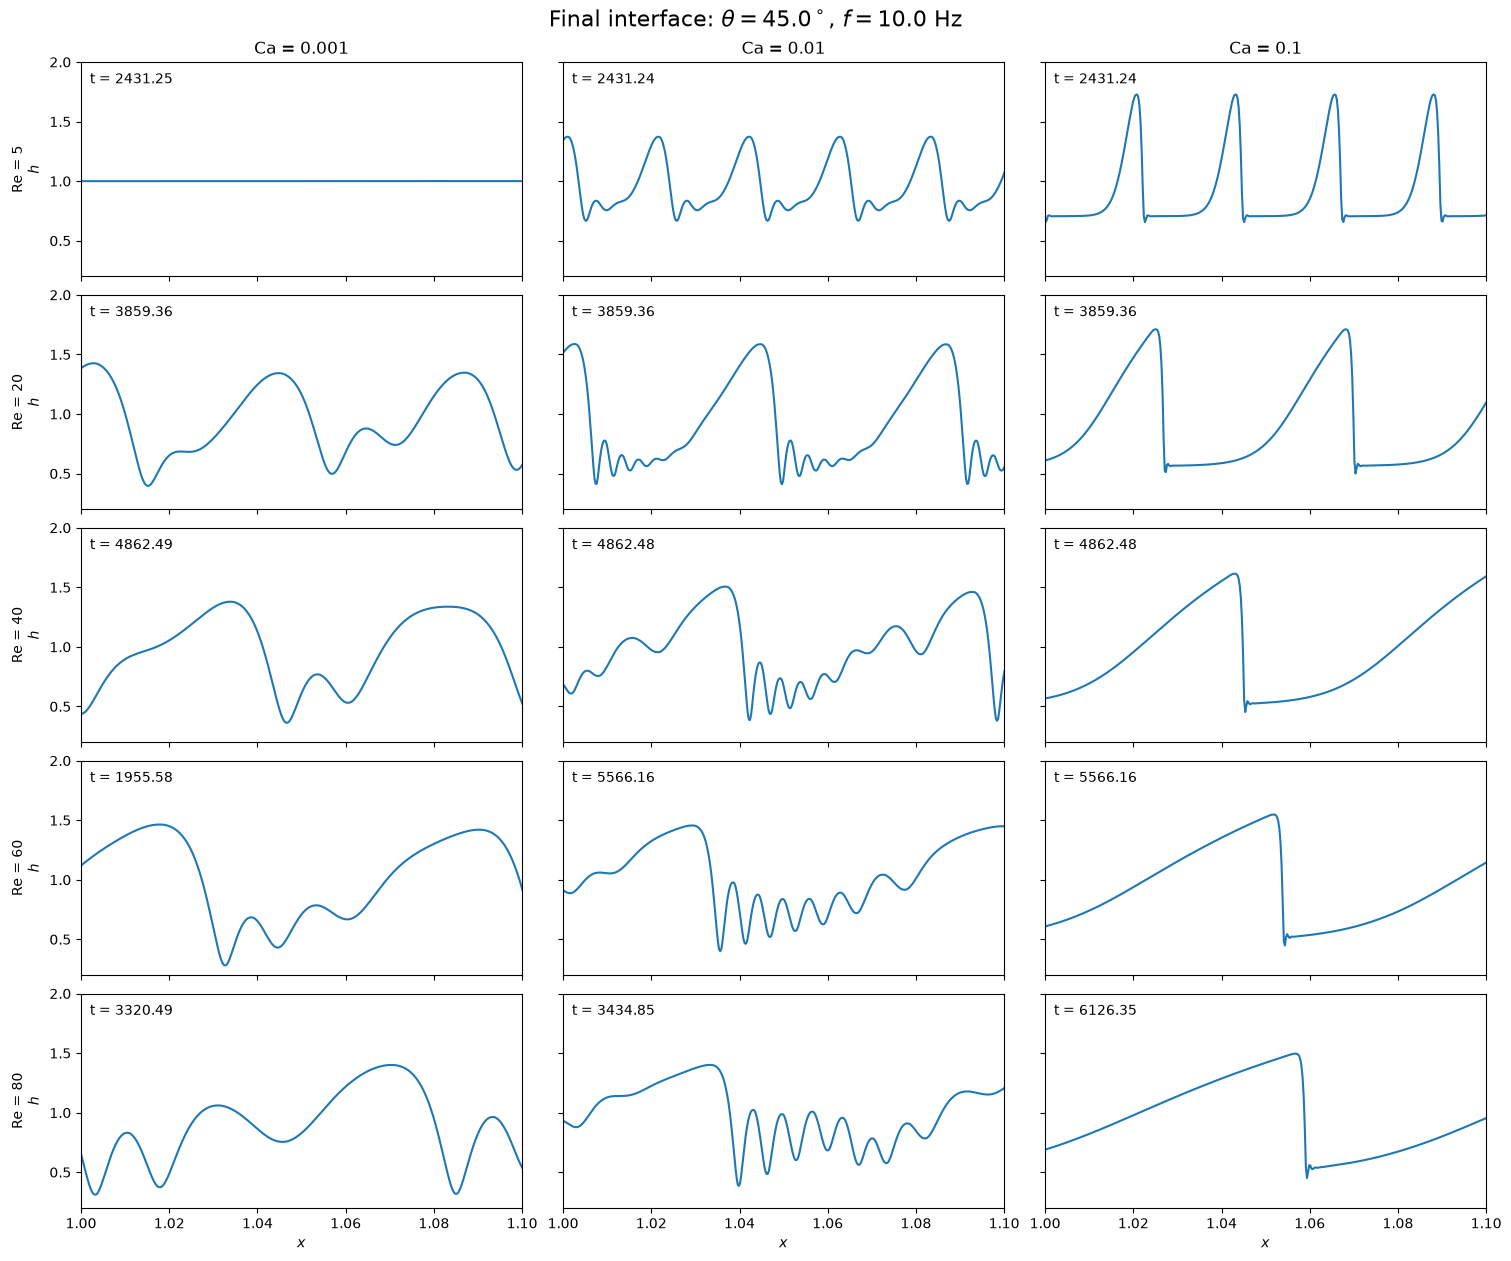

In [7]:
nrows = len(Re_values)
ncols = len(Ca_values)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 2.5 * nrows),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# Make axes always 2D
axes = np.atleast_2d(axes)

for i, Re in enumerate(Re_values):
    for j, Ca in enumerate(Ca_values):

        ax = axes[i, j]

        try:
            file_path = get_thinfilm_file_path(
                parent_dir,
                Ca=Ca,
                Re=Re,
                theta=theta,
                f=f
            )

            with h5py.File(file_path, "r") as file:
                x = file["x"][:].squeeze()
                time = file["time"][:].squeeze()
                h_final = file["h"][:, -1]
                hN = file.attrs["hN"][0]

            ax.plot(x*hN, h_final)

            # Show final time inside panel
            ax.text(
                0.02,
                0.95,
                f"t = {time[-1]:.2f}",
                transform=ax.transAxes,
                va="top"
            )

        except FileNotFoundError:
            ax.text(
                0.5,
                0.5,
                "File not found",
                transform=ax.transAxes,
                ha="center",
                va="center"
            )

        # Column titles = Ca
        if i == 0:
            ax.set_title(f"Ca = {Ca:g}")

        # Row labels = Re
        if j == 0:
            ax.set_ylabel(f"Re = {Re}\n$h$")

        # x labels only on bottom row
        if i == nrows - 1:
            ax.set_xlabel("$x$")
            
        ax.set_xlim(1.0, 1.1)
        ax.set_ylim(0.2, 2.0)


fig.suptitle(
    rf"Final interface: $\theta={theta}^\circ$, $f={f}$ Hz",
    fontsize=16
)

plt.show()

Plotting coefficients

In [9]:
Ca = 0.01
Re = 20
theta = 45
f = 10

file_path = get_thinfilm_file_path(
                parent_dir,
                Ca=Ca,
                Re=Re,
                theta=theta,
                f=f
            )
            

with h5py.File(file_path, "r") as file:
    x = file["x"][:].squeeze()
    time = file["time"][:].squeeze()
    h   = file["h"][:]
    h_x = file["h_x"][:]
    h_xx = file["h_xx"][:]
    h_xxx = file["h_xxx"][:]
    h_t = file["h_t"][:]
    q   = file["q"][:]
    q_x = file["q_x"][:]
    q_xx = file["q_xx"][:]
    q_t = file["q_t"][:]

    hN = float(file.attrs["hN"][0])

In [10]:
tol = 1e-8

# A point is undisturbed only if BOTH h and q are approximately 1
undisturbed = (
    np.isclose(h, 1.0, atol=tol, rtol=0.0)
    & np.isclose(q, 1.0, atol=tol, rtol=0.0)
)

# Therefore a point is disturbed if either h or q differs from 1
disturbed = ~undisturbed

keep_mask = np.maximum.accumulate(
    disturbed[::-1, :],
    axis=0
)[::-1, :]

h_filtered   = h[keep_mask]
hx_filtered  = h_x[keep_mask]
hxx_filtered  = h_xx[keep_mask]
hxxx_filtered  = h_xxx[keep_mask]
ht_filtered  = h_t[keep_mask]
q_filtered   = q[keep_mask]
qx_filtered  = q_x[keep_mask]
qxx_filtered  = q_xx[keep_mask]
qt_filtered  = q_t[keep_mask]

total_points = keep_mask.size
kept_points = np.count_nonzero(keep_mask)
discarded_points = total_points - kept_points

print(f"Total data points:     {total_points:,}")
print(f"Kept data points:      {kept_points:,}")
print(f"Discarded data points: {discarded_points:,}")
print(f"Discarded fraction:    {discarded_points / total_points:.2%}")

Total data points:     12,000,000
Kept data points:      10,987,875
Discarded data points: 1,012,125
Discarded fraction:    8.43%


In [11]:
df = pd.DataFrame({
    "h": h_filtered,
    "h_x": hx_filtered,
    "h_xx": hxx_filtered,
    "h_xxx": hxxx_filtered,
    "h_t": ht_filtered,
    "q": q_filtered,
    "q_x": qx_filtered,
    "q_xx": qxx_filtered,
    "q_t": qt_filtered,
})

pearson_corr = df.corr(method="pearson")

display(pearson_corr)

,h,h_x,h_xx,h_xxx,h_t,q,q_x,q_xx,q_t
h,1.000000,0.000536,-0.257489,-0.000124,-0.003426,0.943776,-0.002550,-0.227649,0.000270
h_x,0.000536,1.000000,0.001281,-0.631352,-0.976331,0.003692,0.979938,-0.006515,-0.845272
h_xx,-0.257489,0.001281,1.000000,0.000966,0.017685,-0.220776,0.008376,0.910628,0.012014
h_xxx,-0.000124,-0.631352,0.000966,1.000000,0.678356,-0.001202,-0.652992,0.007329,0.659525
h_t,-0.003426,-0.976331,0.017685,0.678356,1.000000,-0.006944,-0.997146,0.027448,0.929408
q,0.943776,0.003692,-0.220776,-0.001202,-0.006944,1.000000,0.001293,-0.204102,-0.003682
q_x,-0.002550,0.979938,0.008376,-0.652992,-0.997146,0.001293,1.000000,0.000241,-0.926748
q_xx,-0.227649,-0.006515,0.910628,0.007329,0.027448,-0.204102,0.000241,1.000000,0.033938
q_t,0.000270,-0.845272,0.012014,0.659525,0.929408,-0.003682,-0.926748,0.033938,1.000000


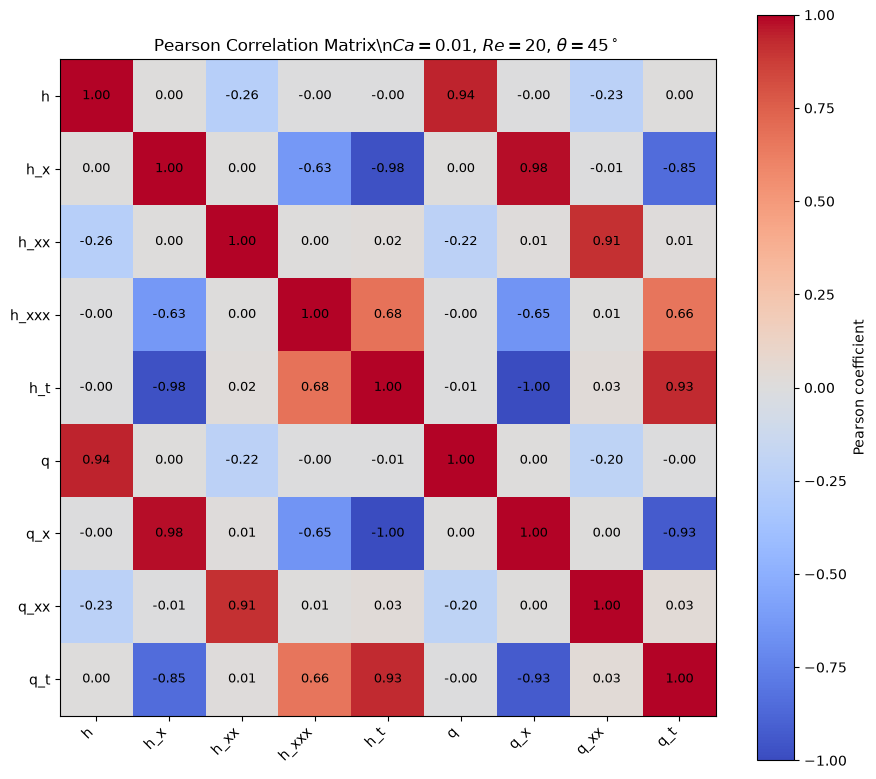

In [12]:
fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    pearson_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

labels = pearson_corr.columns

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# Write the correlation values on the heatmap
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(
            j,
            i,
            f"{pearson_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
        )

plt.colorbar(im, ax=ax, label="Pearson coefficient")

plt.title(
    rf"Pearson Correlation Matrix\n"
    rf"$Ca={Ca}$, $Re={Re}$, $\theta={theta}^\circ$"
)

plt.tight_layout()
plt.show()